<a href="https://colab.research.google.com/github/gmauricio-toledo/tda/blob/main/notebooks/04-Homolog%C3%ADa_Persistente.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<h1>Homología Persistente</h1>

En esta notebook experimentaremos con la Homología Persistente. Primero ilustraremos las coordenadas baricéntricas para definir puntos dentro de simplejos. Posteriormente, construimos los complejos de Cech y Vietoris-Rips.

# Preliminares

In [9]:
!pip install ripser persim

In [10]:
!pip install gudhi

In [15]:
!pip install -U giotto-tda

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 24.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 92.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 557.0/557.0 kB 31.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.7/5.7 MB 68.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 82.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 457.9/457.9 kB 26.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 60.9 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.6.1
    Uninstalling scikit-learn-1.6.1:
      Successfully uninstalled scikit-learn-1.6.1
ERROR: pip's dependency resolver does not cur

Ejemplo 1: Circulo con ruido

(30, 2)


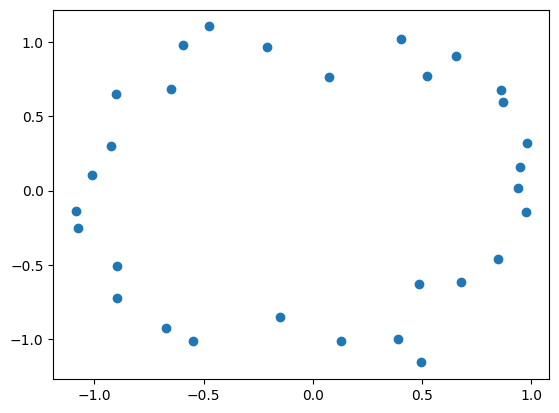

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Ejemplo 1: Círculo ruidoso
theta = np.linspace(0, 2*np.pi, 30)
X = np.column_stack([np.cos(theta), np.sin(theta)])
X += np.random.normal(0, 0.1, X.shape)
print(X.shape)

plt.figure()
plt.scatter(X[:, 0], X[:, 1])
plt.show()

Ejemplo 2: Dos círculos concéntricos con ruido

(70, 2)


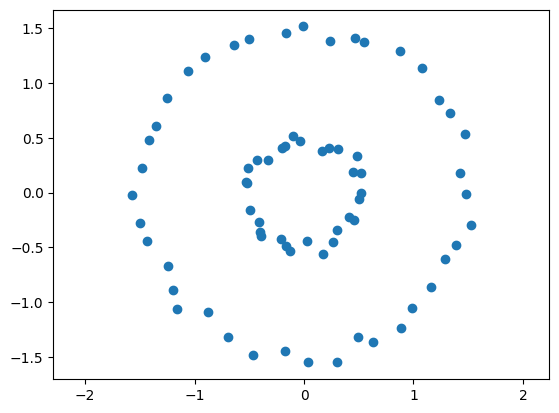

In [4]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
n_inner, n_outer = 30, 40

theta_inner = np.linspace(0, 2*np.pi, n_inner, endpoint=False)
X_inner = 0.5 * np.column_stack([np.cos(theta_inner), np.sin(theta_inner)])
X_inner += np.random.normal(0, 0.05, X_inner.shape)

theta_outer = np.linspace(0, 2*np.pi, n_outer, endpoint=False)
X_outer = 1.5 * np.column_stack([np.cos(theta_outer), np.sin(theta_outer)])
X_outer += np.random.normal(0, 0.05, X_outer.shape)

X = np.vstack([X_inner, X_outer])

print(X.shape)

plt.figure()
plt.scatter(X[:, 0], X[:, 1])
plt.axis('equal')
# plt.axis('off')
plt.show()

# Ejemplos *reales*

## Ejemplo 1


(300, 2)


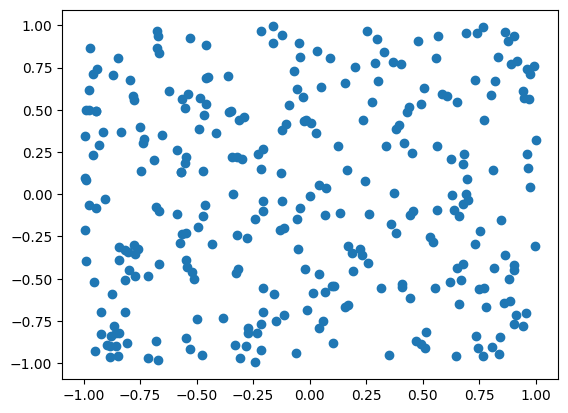

In [1]:
import numpy as np
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt


X, _ = make_blobs(n_samples=300,
                  n_features=2,
                  centers=5,
                  random_state=558)
X = np.random.uniform(low=-1, high=1, size=(300, 2))


print(X.shape)

plt.figure()
plt.scatter(X[:,0],X[:,1])
plt.show()

In [ ]:
from ripser import Rips
from persim import plot_diagrams

rips = Rips(maxdim=1)
diagram = rips.fit_transform(X)

plt.figure()
plot_diagrams(diagram, legend=True)
plt.show()

## Ejemplo 2

https://github.com/DCDPUAEM/DCDP/blob/main/04%20Deep%20Learning/notebooks/07-Autoencoders.ipynb

In [ ]:
!gdown 1mqfspvk8kqG0hMHeiIXJ3UHIQHXLO-gv
!gdown 1Q89lbS06bdLG1N8FKHtefvrpT0XmaFRt

In [ ]:
periodic = np.loadtxt('periodic_signal.txt')
nonperiodic = np.loadtxt('nonperiodic_signal.txt')
print(f"Periodic: {periodic.shape}")
print(f"Nonperiodic: {nonperiodic.shape}")

plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.plot(periodic[:500], 'b-', linewidth=0.8)
plt.subplot(1,2,2)
plt.plot(nonperiodic[:500], 'r-', linewidth=0.8)
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from ripser import ripser
from persim import plot_diagrams
from scipy.spatial.distance import pdist

def takens_embedding(signal, tau, d):
    n = len(signal) - (d-1)*tau
    embedded = np.zeros((n, d))
    for i in range(d):
        embedded[:, i] = signal[i*tau : i*tau + n]
    return embedded

def analyze_signal_topology(signal, tau, d=3, label="Signal"):
    """
    Análisis topológico minimal de una señal.
    """
    # Embeddings normalizados
    embedded = takens_embedding(signal, tau, d)
    embedded = (embedded - embedded.mean(axis=0)) / embedded.std(axis=0)

    # Subsampleo (para eficiencia)
    step = max(1, len(embedded) // 300)
    embedded_sub = embedded[::step]

    # Distancias
    dists = pdist(embedded_sub)
    p90 = np.percentile(dists, 90)

    # Homología persistente
    thresh = 1.3*p90
    result = ripser(embedded_sub, maxdim=1, thresh=thresh)
    dgm0 = result['dgms'][0]
    dgm1 = result['dgms'][1]

    # Filtrar infinitos
    dgm1_finite = dgm1[dgm1[:, 1] < np.inf]

    # Análisis
    if len(dgm1_finite) > 0:
        pers = dgm1_finite[:, 1] - dgm1_finite[:, 0]  # TIEMPO DE VIDA

        # Ciclos significativos
        threshold_pers = 0.3 * pers.max()
        significant = pers > threshold_pers
        n_sig = significant.sum()

        top5 = np.sort(pers)[-5:][::-1] if len(pers) >= 5 else np.sort(pers)[::-1]

        print(f"\nH1 (1-ciclos):")
        print(f"  Total: {len(dgm1_finite)}")
        print(f"  Significativos (>30% persistencia máxima): {n_sig}")
        print(f"  Top 5 persistencias: {top5}")

        if len(top5) > 1:
            ratio = top5[0] / top5[1]
            print(f"  Ratio top1/top2: {ratio:.2f}")

    else:
        print("\nNo se detectaron 1-ciclos significativos")

    return embedded, dgm0, dgm1

In [ ]:
# ============================================================
# EJEMPLO 1: SEÑAL PERIÓDICA PURA
# ============================================================
print("\n" + "="*60)
print("EJEMPLO 1: SEÑAL PERIÓDICA")
print("="*60)

emb1, _, dgm1_1 = analyze_signal_topology(
                    periodic,
                    tau=15,
                    d=3,
                    label="SEÑAL PERIÓDICA"
                )

# ============================================================
# EJEMPLO 2: SISTEMA CAÓTICO
# ============================================================
print("\n" + "="*60)
print("EJEMPLO 2: SEÑAL IRREGULAR")
print("="*60)

emb2, _, dgm1_2 = analyze_signal_topology(
                    nonperiodic,
                    tau=10,
                    d=3,
                    label="SEÑAL CAÓTICA"
                )

# ======== GRÁFICAS ======================
fig = plt.figure(figsize=(16, 10))

# Señales temporales
ax1 = plt.subplot(2,3,1)
ax1.plot(periodic[:500], 'b-', linewidth=0.8)
ax1.set_title('Señal periódica')
ax1.set_xlabel('Tiempo')

# Embeddings Takens
ax2 = plt.subplot(2, 3, 2)
ax2.scatter(emb1[:, 0], emb1[:, 1], color='b', s=10)
ax2.set_title('Embeddings de Takens')
ax2.set_xlabel('x(t)')
ax2.set_ylabel('x(t+tau)')
ax2.set_aspect('equal')

# Diagramas de persistencia
ax3 = plt.subplot(2, 3, 3)
plot_diagrams([dgm1_1], ax=ax3, legend=False)
ax3.set_title('Diagrama Periódica')

# Señales temporales
ax4 = plt.subplot(2, 3, 4)
ax4.plot(nonperiodic[:500], 'r-', linewidth=0.8)
ax4.set_title('Señal irregular')
ax4.set_xlabel('Tiempo')

# Embeddings Takens
ax5 = plt.subplot(2, 3, 5)
ax5.scatter(emb2[:, 0], emb2[:, 1], color='r', s=10)
ax5.set_title('Embeddings de Takens')
ax5.set_xlabel('x(t)')
ax5.set_ylabel('x(t+tau)')
ax5.set_aspect('equal')

# Diagrama de persistencia
ax6 = plt.subplot(2, 3, 6)
plot_diagrams([dgm1_2], ax=ax6, legend=False)
ax6.set_title('Diagrama irregular')


plt.tight_layout()
plt.savefig('tda_periodic_signals.png', dpi=200, bbox_inches='tight')
plt.show()


# Comparación de librerias

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import pdist, squareform
import warnings
warnings.filterwarnings('ignore')

# Configuración de gráficas
plt.style.use('seaborn-v0_8-darkgrid')
%matplotlib inline

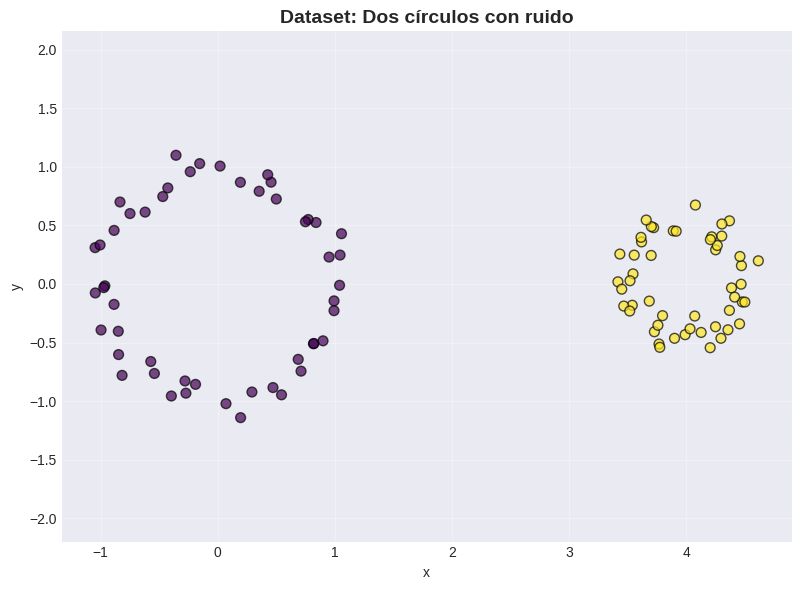

Dataset shape: (100, 2)
Rango X: [-1.05, 4.62]
Rango Y: [-1.14, 1.10]


In [4]:
def generate_noisy_circles(n_samples=100, noise=0.05, random_state=42):
    """
    Genera dos círculos con ruido gaussiano
    - Círculo 1: radio 1, centrado en (0, 0)
    - Círculo 2: radio 0.5, centrado en (4, 0)
    """
    np.random.seed(random_state)

    # Círculo grande
    theta1 = np.linspace(0, 2*np.pi, n_samples//2, endpoint=False)
    circle1 = np.column_stack([np.cos(theta1), np.sin(theta1)])
    circle1 += np.random.normal(0, noise, circle1.shape)

    # Círculo pequeño (desplazado)
    theta2 = np.linspace(0, 2*np.pi, n_samples//2, endpoint=False)
    circle2 = 0.5 * np.column_stack([np.cos(theta2), np.sin(theta2)])
    circle2 += np.array([4, 0])  # Desplazar
    circle2 += np.random.normal(0, noise, circle2.shape)

    # Combinar
    X = np.vstack([circle1, circle2])
    labels = np.hstack([np.zeros(n_samples//2), np.ones(n_samples//2)])

    return X, labels

# Generar datos
X, labels = generate_noisy_circles(n_samples=100, noise=0.08)

# Visualizar
fig, ax = plt.subplots(1, 1, figsize=(8, 6))
scatter = ax.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis',
                     s=50, alpha=0.7, edgecolors='black')
ax.set_title('Dataset: Dos círculos con ruido', fontsize=14, fontweight='bold')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.axis('equal')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Dataset shape: {X.shape}")
print(f"Rango X: [{X[:, 0].min():.2f}, {X[:, 0].max():.2f}]")
print(f"Rango Y: [{X[:, 1].min():.2f}, {X[:, 1].max():.2f}]")

## Ripser

RIPSER - Ultra-rápido, solo Vietoris-Rips

  Tiempo de cómputo: 0.1642 segundos

 Diagramas de persistencia:
  H_0: 99 features finitos, 1 infinitos
  H_1: 5 features finitos, 0 infinitos
  H_2: 3 features


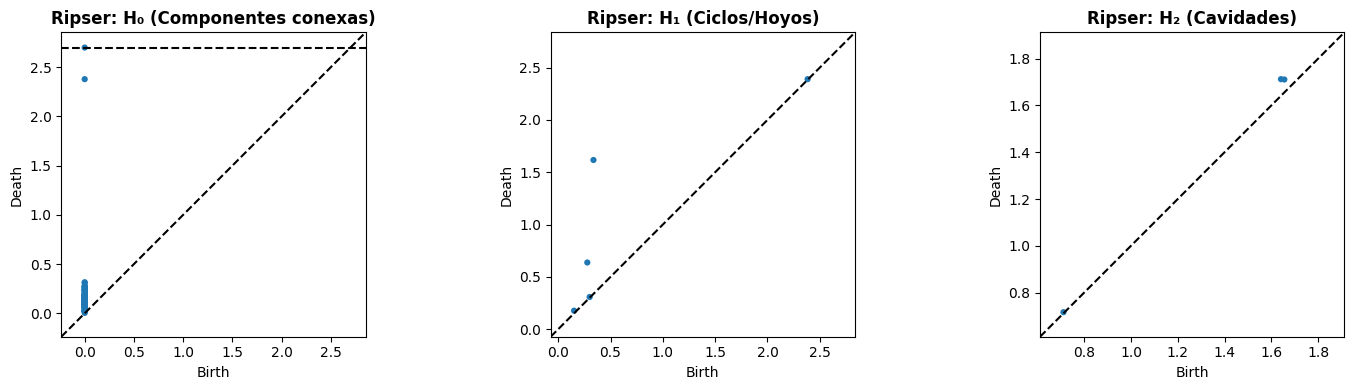


 Análisis H₁:
  Número de ciclos finitos: 5
  Persistencia máxima: 1.280
  Persistencia media: 0.335

  Top 5 features más persistentes:
    1. Birth=0.337, Death=1.617, Persistence=1.280
    2. Birth=0.278, Death=0.637, Persistence=0.359
    3. Birth=0.152, Death=0.177, Persistence=0.025
    4. Birth=0.300, Death=0.307, Persistence=0.007
    5. Birth=2.383, Death=2.389, Persistence=0.006


In [13]:
from ripser import ripser
from persim import plot_diagrams
import time

print("="*60)
print("RIPSER - Ultra-rápido, solo Vietoris-Rips")
print("="*60)

# Computar persistencia
start_time = time.time()
result_ripser = ripser(X, maxdim=2, thresh=3.0)
time_ripser = time.time() - start_time

diagrams_ripser = result_ripser['dgms']

print(f"\n  Tiempo de cómputo: {time_ripser:.4f} segundos")
print(f"\n Diagramas de persistencia:")
for dim, dgm in enumerate(diagrams_ripser):
    n_features = len(dgm)
    if dim < len(diagrams_ripser) - 1:  # Excluir features infinitos en H₀
        n_features_finite = np.sum(np.isfinite(dgm[:, 1]))
        print(f"  H_{dim}: {n_features_finite} features finitos, {n_features - n_features_finite} infinitos")
    else:
        print(f"  H_{dim}: {n_features} features")

# Visualización con persim
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Diagrama H₀
plot_diagrams(diagrams_ripser[0:1], ax=axes[0], legend=False)
axes[0].set_title('Ripser: H₀ (Componentes conexas)', fontweight='bold')

# Diagrama H₁
plot_diagrams(diagrams_ripser[1:2], ax=axes[1], legend=False)
axes[1].set_title('Ripser: H₁ (Ciclos/Hoyos)', fontweight='bold')

# Diagrama H₂
plot_diagrams(diagrams_ripser[2:3], ax=axes[2], legend=False)
axes[2].set_title('Ripser: H₂ (Cavidades)', fontweight='bold')

plt.tight_layout()
plt.show()

# Análisis de persistencia (H₁)
dgm_h1 = diagrams_ripser[1]
dgm_h1_finite = dgm_h1[np.isfinite(dgm_h1[:, 1])]
if len(dgm_h1_finite) > 0:
    persistence_h1 = dgm_h1_finite[:, 1] - dgm_h1_finite[:, 0]
    print(f"\n Análisis H₁:")
    print(f"  Número de ciclos finitos: {len(dgm_h1_finite)}")
    print(f"  Persistencia máxima: {persistence_h1.max():.3f}")
    print(f"  Persistencia media: {persistence_h1.mean():.3f}")

    # Mostrar top 5 features más persistentes
    top_indices = np.argsort(persistence_h1)[::-1][:5]
    print(f"\n  Top 5 features más persistentes:")
    for i, idx in enumerate(top_indices, 1):
        birth, death = dgm_h1_finite[idx]
        pers = death - birth
        print(f"    {i}. Birth={birth:.3f}, Death={death:.3f}, Persistence={pers:.3f}")

## GUDHI


GUDHI - Completo, múltiples complejos y coeficientes

--- Vietoris-Rips Complex ---
⏱Tiempo de cómputo (VR): 0.0351 segundos
Simplex tree info:
  Número de vértices: 100
  Número de simplices: 46005

--- Alpha Complex ---
Tiempo de cómputo (Alpha): 0.0421 segundos
Simplex tree info:
  Número de vértices: 100
  Número de simplices: 569


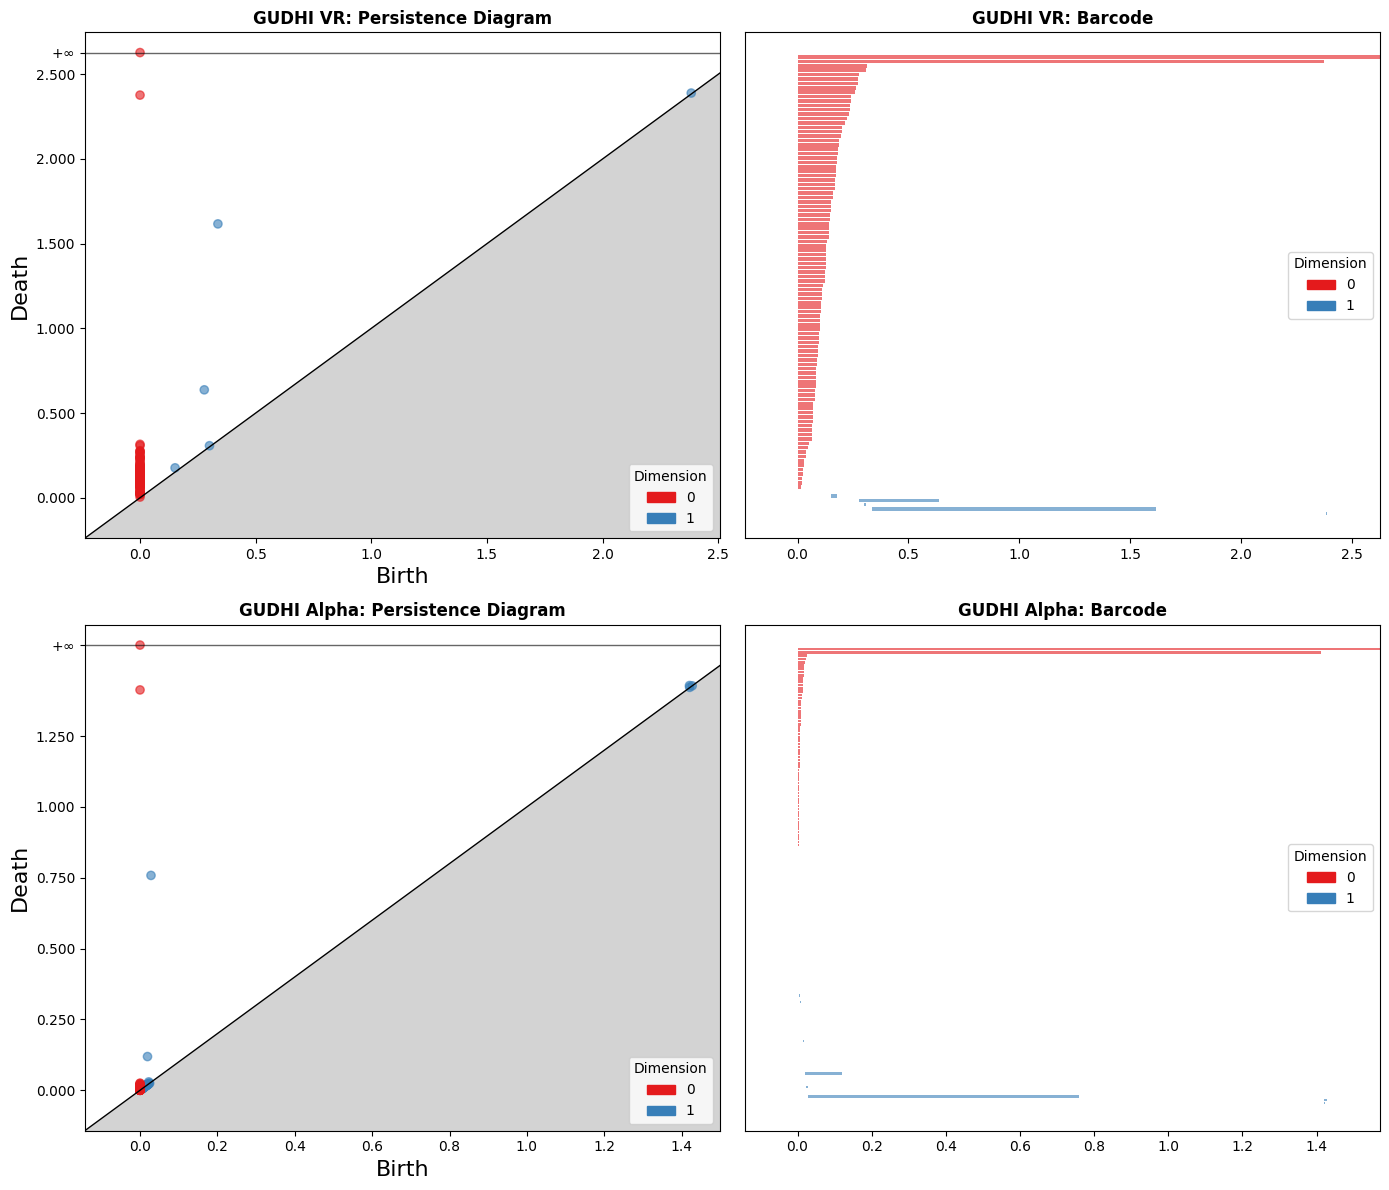


🔍 Comparación VR vs Alpha (H₁):
  VR: 5 ciclos finitos
  Alpha: 41 ciclos finitos

  Bottleneck distance (VR vs Alpha, H₁): 0.6400
  → Los diagramas son diferentes


In [11]:
import gudhi
import time

print("\n" + "="*60)
print("GUDHI - Completo, múltiples complejos y coeficientes")
print("="*60)

# Opción 1: Vietoris-Rips (comparable con Ripser)
print("\n--- Vietoris-Rips Complex ---")

start_time = time.time()
rips_complex = gudhi.RipsComplex(points=X, max_edge_length=3.0)
simplex_tree_rips = rips_complex.create_simplex_tree(max_dimension=2)
persistence_rips = simplex_tree_rips.persistence()
time_gudhi_rips = time.time() - start_time

print(f"Tiempo de cómputo (VR): {time_gudhi_rips:.4f} segundos")
print(f"Simplex tree info:")
print(f"  Número de vértices: {simplex_tree_rips.num_vertices()}")
print(f"  Número de simplices: {simplex_tree_rips.num_simplices()}")

# Opción 2: Alpha Complex (más eficiente para datos en R2 o R3)
print("\n--- Alpha Complex ---")

start_time = time.time()
alpha_complex = gudhi.AlphaComplex(points=X)
simplex_tree_alpha = alpha_complex.create_simplex_tree()
persistence_alpha = simplex_tree_alpha.persistence()
time_gudhi_alpha = time.time() - start_time

print(f"Tiempo de cómputo (Alpha): {time_gudhi_alpha:.4f} segundos")
print(f"Simplex tree info:")
print(f"  Número de vértices: {simplex_tree_alpha.num_vertices()}")
print(f"  Número de simplices: {simplex_tree_alpha.num_simplices()}")

# Visualización GUDHI nativa
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# VR - Diagram
gudhi.plot_persistence_diagram(persistence_rips, axes=axes[0, 0])
axes[0, 0].set_title('GUDHI VR: Persistence Diagram', fontweight='bold')

# VR - Barcode
gudhi.plot_persistence_barcode(persistence_rips, axes=axes[0, 1])
axes[0, 1].set_title('GUDHI VR: Barcode', fontweight='bold')

# Alpha - Diagram
gudhi.plot_persistence_diagram(persistence_alpha, axes=axes[1, 0])
axes[1, 0].set_title('GUDHI Alpha: Persistence Diagram', fontweight='bold')

# Alpha - Barcode
gudhi.plot_persistence_barcode(persistence_alpha, axes=axes[1, 1])
axes[1, 1].set_title('GUDHI Alpha: Barcode', fontweight='bold')

plt.tight_layout()
plt.show()

# Comparar VR vs Alpha
print("\n Comparación VR vs Alpha (H₁):")

# Extraer H₁ de VR
h1_rips = [p for p in persistence_rips if p[0] == 1]
h1_rips_finite = [(p[1][0], p[1][1]) for p in h1_rips if p[1][1] != float('inf')]
print(f"  VR: {len(h1_rips_finite)} ciclos finitos")

# Extraer H₁ de Alpha
h1_alpha = [p for p in persistence_alpha if p[0] == 1]
h1_alpha_finite = [(p[1][0], p[1][1]) for p in h1_alpha if p[1][1] != float('inf')]
print(f"  Alpha: {len(h1_alpha_finite)} ciclos finitos")

# Bottleneck distance entre diagramas
# Convertir a formato GUDHI
dgm_rips_h1 = np.array([[p[1][0], p[1][1]] for p in h1_rips if p[1][1] != float('inf')])
dgm_alpha_h1 = np.array([[p[1][0], p[1][1]] for p in h1_alpha if p[1][1] != float('inf')])

if len(dgm_rips_h1) > 0 and len(dgm_alpha_h1) > 0:
    bottleneck_dist = gudhi.bottleneck_distance(dgm_rips_h1, dgm_alpha_h1)
    print(f"\n  Bottleneck distance (VR vs Alpha, H₁): {bottleneck_dist:.4f}")
    print(f"  → Los diagramas son {'muy similares' if bottleneck_dist < 0.1 else 'diferentes'}")

## [GIOTTO-TDA](https://giotto-ai.github.io/gtda-docs/latest/index.html)


GIOTTO-TDA - Integración con scikit-learn
Input shape: (1, 100, 2)
  n_samples (point clouds): 1
  n_points por cloud: 100
  n_dimensions: 2

--- Persistencia ---
  Tiempo de cómputo: 0.0586 segundos
 Diagrams shape: (1, 107, 3)
  (n_samples, n_features, 3) donde 3 = (birth, death, dimension)


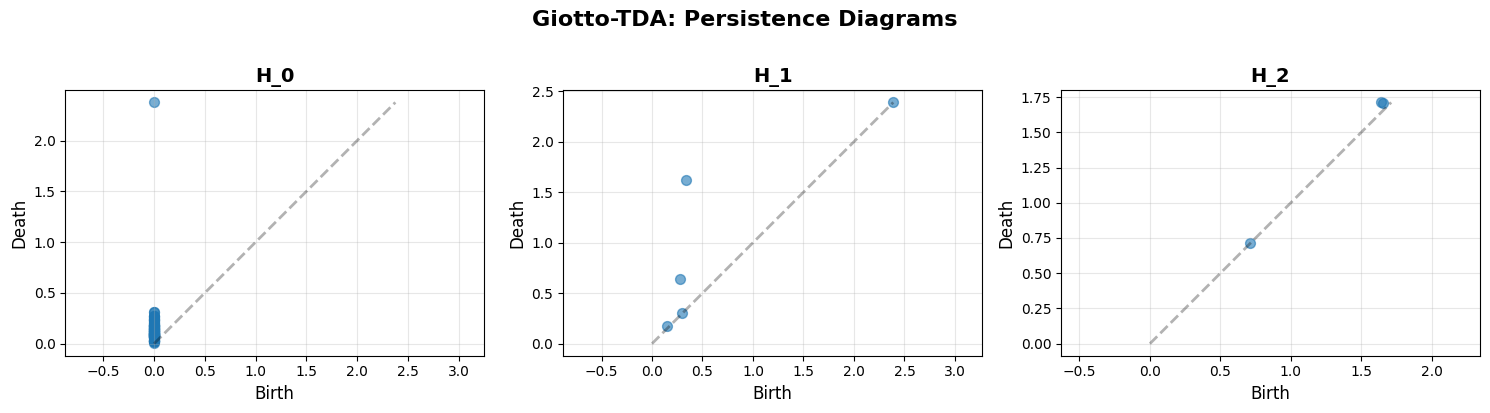


--- Vectorización para ML ---

1. Persistence Entropy:
   Shape: (1, 3)
   Values: [6.02295697 0.92576282 1.17833391]

2. Amplitudes (bottleneck):
   Shape: (1, 3)
   Values: [1.18860078 0.64001477 0.03561771]

3. Betti Curves:
   Shape: (1, 3, 100)
   (n_samples, n_bins, n_homology_dimensions)


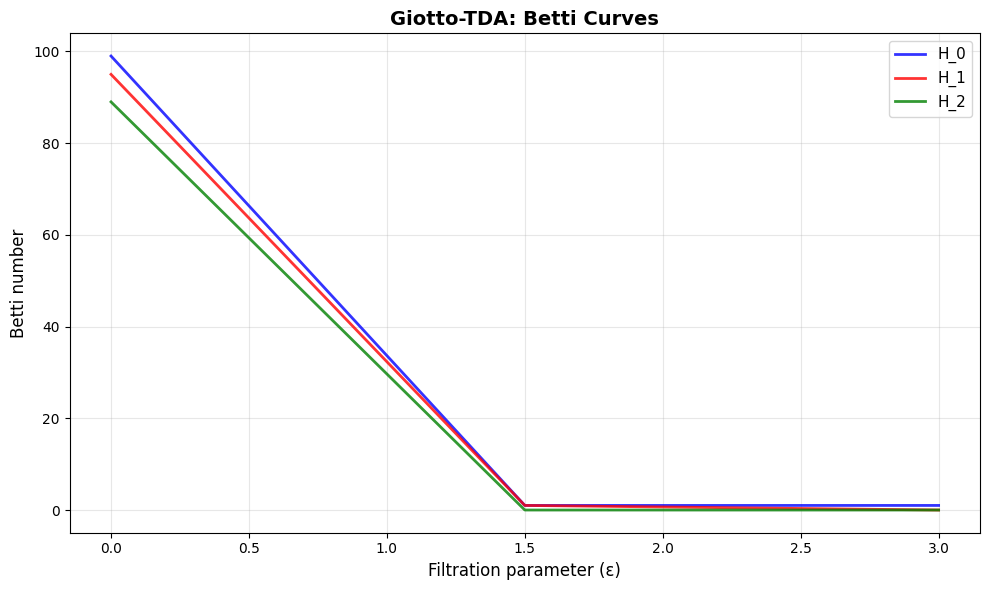

In [24]:
# ============================================
# GIOTTO-TDA
# ============================================

from gtda.homology import VietorisRipsPersistence
from gtda.diagrams import PersistenceEntropy, Amplitude, BettiCurve, PersistenceLandscape
import time

print("\n" + "="*60)
print("GIOTTO-TDA - Integración con scikit-learn")
print("="*60)

# Giotto trabaja con batches de point clouds
# Formato: array de shape (n_samples, n_points, n_dimensions)
X_batch = X[np.newaxis, :, :]  # (1, 100, 2)

print(f"Input shape: {X_batch.shape}")
print(f"  n_samples (point clouds): {X_batch.shape[0]}")
print(f"  n_points por cloud: {X_batch.shape[1]}")
print(f"  n_dimensions: {X_batch.shape[2]}")

# Computar persistencia
print("\n--- Persistencia ---")
start_time = time.time()
vr = VietorisRipsPersistence(homology_dimensions=[0, 1, 2],
                             max_edge_length=3.0,
                             n_jobs=1)
diagrams_giotto = vr.fit_transform(X_batch)
time_giotto = time.time() - start_time

print(f"  Tiempo de cómputo: {time_giotto:.4f} segundos")
print(f" Diagrams shape: {diagrams_giotto.shape}")
print(f"  (n_samples, n_features, 3) donde 3 = (birth, death, dimension)")

# Visualización con matplotlib (más estable que Plotly en Colab)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Extraer diagramas por dimensión
for dim, ax in enumerate(axes):
    # Filtrar features de dimensión específica
    dgm_dim = diagrams_giotto[0][diagrams_giotto[0][:, 2] == dim]

    if len(dgm_dim) > 0:
        births = dgm_dim[:, 0]
        deaths = dgm_dim[:, 1]

        # Scatter plot
        ax.scatter(births, deaths, alpha=0.6, s=50)

        # Diagonal y=x
        max_val = max(deaths.max(), births.max()) if len(deaths) > 0 else 1
        ax.plot([0, max_val], [0, max_val], 'k--', alpha=0.3, linewidth=2)

        ax.set_xlabel('Birth', fontsize=12)
        ax.set_ylabel('Death', fontsize=12)
        ax.set_title(f'H_{dim}', fontweight='bold', fontsize=14)
        ax.grid(True, alpha=0.3)
        ax.axis('equal')
    else:
        ax.text(0.5, 0.5, f'No features in H_{dim}',
                ha='center', va='center', transform=ax.transAxes)
        ax.set_title(f'H_{dim}', fontweight='bold', fontsize=14)

plt.suptitle('Giotto-TDA: Persistence Diagrams', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Vectorización: Convertir diagramas a features para ML
print("\n--- Vectorización para ML ---")

# Opción 1: Persistence Entropy
pe = PersistenceEntropy()
entropy_features = pe.fit_transform(diagrams_giotto)
print(f"\n1. Persistence Entropy:")
print(f"   Shape: {entropy_features.shape}")
print(f"   Values: {entropy_features[0]}")

# Opción 2: Amplitudes (estadísticos de diagramas)
amp = Amplitude(metric='bottleneck')
amplitude_features = amp.fit_transform(diagrams_giotto)
print(f"\n2. Amplitudes (bottleneck):")
print(f"   Shape: {amplitude_features.shape}")
print(f"   Values: {amplitude_features[0]}")

# Opción 3: Betti Curves
bc = BettiCurve(n_bins=100)
betti_curves = bc.fit_transform(diagrams_giotto)
print(f"\n3. Betti Curves:")
print(f"   Shape: {betti_curves.shape}")
print(f"   (n_samples, n_bins, n_homology_dimensions)")

# Visualizar Betti curves manualmente (más robusto que plot_betti_curves)
n_bins = betti_curves.shape[1]
samplings = np.linspace(0, 3.0, n_bins)

fig, ax = plt.subplots(1, 1, figsize=(10, 6))

# Graficar cada dimensión homológica
# homology_dims = betti_curves.shape[2]
homology_dims = 3
colors = ['blue', 'red', 'green', 'orange', 'purple']
labels = [f'H_{i}' for i in range(homology_dims)]

for dim in range(homology_dims):
    ax.plot(samplings, betti_curves[0, :, dim],
            label=labels[dim],
            color=colors[dim % len(colors)],
            linewidth=2,
            alpha=0.8)

ax.set_xlabel('Filtration parameter (ε)', fontsize=12)
ax.set_ylabel('Betti number', fontsize=12)
ax.set_title('Giotto-TDA: Betti Curves', fontweight='bold', fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Comparación de performance


COMPARACIÓN DE TIEMPOS DE CÓMPUTO
     Librería  Tiempo (s)  Speedup vs Ripser
       Ripser      0.1642               1.00
   GUDHI (VR)      0.0351               4.68
GUDHI (Alpha)      0.0421               3.90
   Giotto-TDA      0.0433               3.79


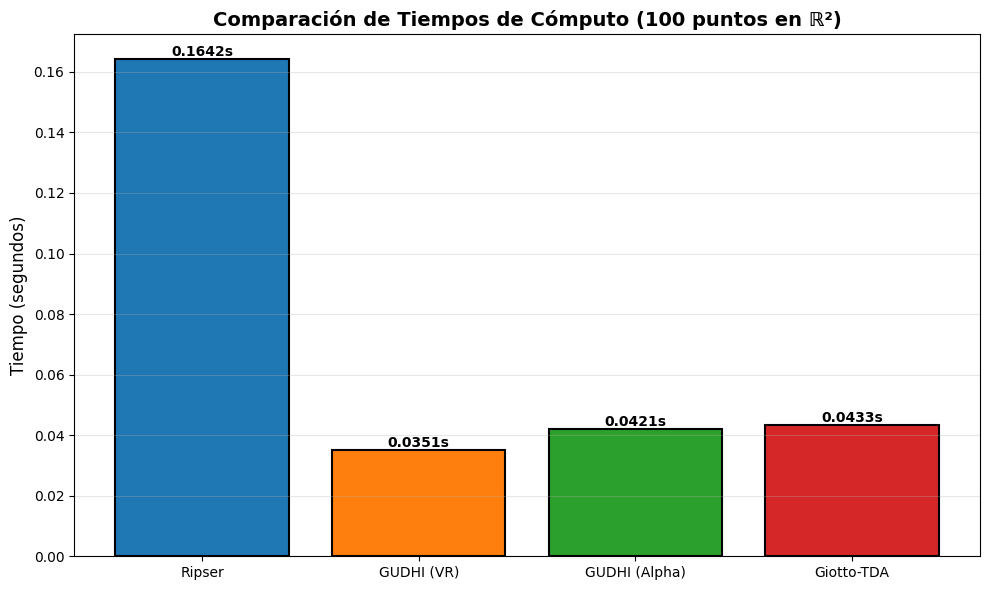

In [14]:
print("\n" + "="*60)
print("COMPARACIÓN DE TIEMPOS DE CÓMPUTO")
print("="*60)

results = {
    'Librería': ['Ripser', 'GUDHI (VR)', 'GUDHI (Alpha)', 'Giotto-TDA'],
    'Tiempo (s)': [time_ripser, time_gudhi_rips, time_gudhi_alpha, time_giotto],
    'Speedup vs Ripser': [
        1.0,
        time_ripser / time_gudhi_rips,
        time_ripser / time_gudhi_alpha,
        time_ripser / time_giotto
    ]
}

import pandas as pd
df_timing = pd.DataFrame(results)
df_timing['Tiempo (s)'] = df_timing['Tiempo (s)'].round(4)
df_timing['Speedup vs Ripser'] = df_timing['Speedup vs Ripser'].round(2)

print(df_timing.to_string(index=False))

# Gráfica de barras
fig, ax = plt.subplots(1, 1, figsize=(10, 6))
bars = ax.bar(df_timing['Librería'], df_timing['Tiempo (s)'],
              color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'],
              edgecolor='black', linewidth=1.5)

# Anotar valores
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.4f}s',
            ha='center', va='bottom', fontweight='bold')

ax.set_ylabel('Tiempo (segundos)', fontsize=12)
ax.set_title('Comparación de Tiempos de Cómputo (100 puntos en ℝ²)',
             fontsize=14, fontweight='bold')
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## Tabla Comparativa de Características

| Característica | Ripser | GUDHI | Giotto-TDA |
|:---------------|:------:|:-----:|:----------:|
| **Complejos Simpliciales** | | | |
| Vietoris-Rips | ✅ | ✅ | ✅ |
| Alpha Complex | ❌ | ✅ | ⚠️ (weak alpha) |
| Čech Complex | ❌ | ✅ | ❌ |
| Cubical Complex | ❌ | ✅ | ✅ |
| Witness Complex | ❌ | ✅ | ❌ |
| Tangential Complex | ❌ | ✅ | ❌ |
| **Coeficientes** | | | |
| ℤ₂ (mod 2) | ✅ | ✅ | ✅ |
| ℤₚ (p primo arbitrario) | ❌ | ✅ | ❌ |
| ℤ (enteros) | ❌ | ✅ | ❌ |
| **Distancias entre Diagramas** | | | |
| Bottleneck distance | ⚠️ (vía persim) | ✅ | ✅ |
| Wasserstein distance | ⚠️ (vía persim) | ✅ | ✅ |
| **Vectorización** | | | |
| Persistence Landscapes | ❌ | ⚠️ (básico) | ✅ |
| Persistence Images | ❌ | ⚠️ (básico) | ✅ |
| Betti Curves | ❌ | ❌ | ✅ |
| Persistence Entropy | ❌ | ❌ | ✅ |
| **Visualización** | | | |
| Diagrams (matplotlib) | ⚠️ (vía persim) | ✅ | ✅ |
| Barcodes | ⚠️ (vía persim) | ✅ | ✅ |
| Diagramas interactivos (Plotly) | ❌ | ❌ | ✅ |
| Persistence density | ❌ | ✅ | ❌ |
| **Integración ML** | | | |
| Scikit-learn transformers | ❌ | ❌ | ✅ |
| Batch processing | ❌ | ❌ | ✅ |
| Pipeline support | ❌ | ❌ | ✅ |
| Cross-validation compatible | ❌ | ❌ | ✅ |
| **Usabilidad** | | | |
| Instalación fácil | ✅ | ⚠️ | ⚠️ |
| API simple | ✅ | ⚠️ | ✅ |
| Documentación | ⭐⭐⭐ | ⭐⭐⭐⭐⭐ | ⭐⭐⭐⭐ |
| Ejemplos/Tutoriales | ⭐⭐⭐ | ⭐⭐⭐⭐⭐ | ⭐⭐⭐⭐ |
| **Performance** | | | |
| Velocidad (VR) | ⭐⭐⭐⭐⭐ | ⭐⭐⭐⭐ | ⭐⭐⭐⭐ |
| Memoria eficiente | ✅ | ✅ | ✅ |
| Paralelización | ⚠️ (limitada) | ✅ | ✅ |

**Leyenda:**
- ✅ = Soportado
- ⚠️ = Soporte parcial o requiere librería adicional
- ❌ = No soportado
- ⭐ = Nivel de calidad (1-5 estrellas)

| Situación | Usar | ¿Por qué? |
|:----------|:---------|:----------|
| **Didáctica TDA** | GUDHI | Ves cada paso del proceso, documentación excelente para entender conceptos |
| **Resultados rápidos** | Ripser | Solo 2 líneas de código, muy veloz |
| **Proyecto de Machine Learning** | Giotto-TDA | Se integra perfecto con sklearn, vectorización automática |
| **Muchos datos (>5000 puntos)** | Ripser | El más rápido  |
| **Varios tipos de complejos** | GUDHI | Tiene VR, Alpha, Čech, Cubical, Witness... |
| **Trabajando con imágenes** | GUDHI Cubical | Diseñado específicamente para grids de píxeles |
| **Visualizaciones atractivas** | Giotto-TDA | Gráficas interactivas con Plotly |

---

## GUDHI: El Laboratorio Completo

**Mejor para:**
- Aprender los conceptos (ves el Simplex Tree, puedes inspeccionar cada estructura)
- Investigación seria (papers, tesis)
- Cuando necesitas Alpha Complex, Cubical, Čech, o Witness
- Imágenes y volúmenes 3D
- Detectar torsión en homología

**Ventajas:**
- ✅ Muchos tipos de complejos disponibles
- ✅ Documentación académica excelente con teoría
- ✅ Coeficientes flexibles (ℤ₂, ℤₚ, ℤ)
- ✅ Bottleneck y Wasserstein distance incluidos

**Desventajas:**
- ❌ API más verbosa (más líneas de código)
- ❌ Instalación puede ser complicada
- ❌ Más lento que Ripser para VR puro

---

## Ripser

**Mejor para:**
- Exploración rápida de datos ("¿hay algo interesante aquí?")
- Datasets grandes (>5000 puntos)
- Cuando solo necesitas Vietoris-Rips
- Prototipado veloz

**Ventajas:**
- ✅ Súper rápido (2-5x más que GUDHI)
- ✅ API minimalista: `ripser(X)` y listo
- ✅ Instalación trivial
- ✅ Memoria eficiente

**Desventajas:**
- ❌ Solo Vietoris-Rips (nada más)
- ❌ Solo coeficientes ℤ₂
- ❌ Sin vectorización automática
- ❌ Visualización requiere librería extra (persim)


---

## Giotto-TDA: El Puente a Machine Learning

**Mejor para:**
- Proyectos de clasificación o regresión con TDA
- Cuando quieres persistencia → features → modelo, todo en un pipeline
- Experimentar con diferentes vectorizaciones (landscapes, entropy, etc.)
- Procesar muchos point clouds a la vez

**Ventajas:**
- ✅ Integración total con sklearn (pipelines, cross-validation, etc.)
- ✅ Vectorización automática (landscapes, images, entropy, amplitudes...)
- ✅ Visualizaciones interactivas atractivas con Plotly
- ✅ Procesa batches de datos
- ✅ Documentación orientada a aplicaciones

**Desventajas:**
- ❌ Abstracciones ocultan detalles (dificulta debugging)
- ❌ Un poco más lento que Ripser/GUDHI directo
- ❌ Instalación puede fallar (depende de GUDHI/Ripser)
- ❌ Menos opciones de complejos que GUDHI



---